# 머신러닝 실습 - 자전거 데이터 분석  

## I. 서론
1. 미션 요구사항
- 자전거 대여 패턴을 분석하여 자전거 배치 및 운영 전략을 최적화하고, 대여 수요를 정확히 예측하는 것입니다.   
이를 통해 대여 시스템의 효율성을 높이고 사용자 만족도를 증가시키는 방법을 찾는 것이 이번 미션의 핵심입니다.
- 이번 미션의 최종 목표는 RMSLE (Root Mean Squared Logarithmic Error)를 최대한 낮추는 것입니다.
다양한 머신러닝 모델과 전략을 실험하여 가장 정확한 수요 예측 모델을 개발하고, 그 결과를 보고서에 담아 보세요!

In [738]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [739]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [740]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## II. EDA

해당 미션의 목표는 입력값을 통해서 목표값(count)을 예측하는 모델을 학습시키는 것입니다.
자전거 변수 분석에 유용하게 사용될 수 있는 몇몇 변수들은 미리 분류 작업을 해 두도록 하겠습니다.

- is_weekend = 주말 여부
- is_rush_hour = 출/퇴근시간

In [741]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['weekday'] = train_df['datetime'].dt.weekday
train_df['hour'] = train_df['datetime'].dt.hour

train_df['is_weekend'] = train_df['weekday'].apply(lambda x: x >= 5).astype(int)
train_df['is_rush_hour'] = train_df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)



### 1. 데이터 설명

| 컬럼명(목표값은 볼드)       | 데이터 타입 | 설명                                                                 |
|--------------|-------------|----------------------------------------------------------------------|
| season       | int         | 계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울)                             |
| holiday      | int         | 공휴일 여부 (0: 평일, 1: 공휴일)                                    |
| workingday   | int         | 근무일 여부 (0: 주말/공휴일, 1: 근무일)                             |
| weather      | int         | 날씨 상황 (1: 맑음, 2: 구름낌/안개, 3: 약간의 비/눈, 4: 폭우/폭설)   |
| temp         | float       | 실측 온도 (섭씨)                                                     |
| atemp        | float       | 체감 온도 (섭씨)                                                     |
| humidity     | int         | 습도 (%)                                                             |
| windspeed    | float       | 풍속 (m/s)                                                           |
| year         | int         | 대여 기록의 연도                                                     |
| month        | int         | 대여 기록의 월                                                       |
| weekday      | int         | 대여 기록의 요일 (0: 월요일 ~ 6: 일요일)                            |
| hour         | int         | 대여 기록의 시간 (0~23시)                                            |
| is_weekend   | int         | 주말 여부 (0: 평일, 1: 주말)                                        |
| is_rush_hour | int         | 출퇴근 시간대 여부 (0: 비혼잡, 1: 혼잡. 07~09시, 17~19시)           |
| **casual**       | int         | 등록되지 않은 사용자의 대여 수                                       |
| **registered**   | int         | 등록된 사용자의 대여 수                                              |
| **count**        | int         | 총 대여 수 (종속 변수)                                               |

EDA에 있어서 가장 중요한 것은 데이터에 대한 이해입니다.
따라서, 이를 진행하기에 앞서 미리 데이터에 대한 설명을 수행합니다.


**!!!주의사항!!!**  
여기서 유의해야 할 점이 있습니다.
count는 casual + registered 값이라는 점입니다.
만약 count를 목표값으로 하는 모델에 casual과 registered 값을 넣으면 데이터 누수가 발생하여, 과적합의 확률이 높아집니다.
때문에 변수 선택 시에 반드시 조심해야 합니다.

### 2. 초기 탐색

초기 탐색에서는 데이터의 대략적인 편향과 분포, 이상치 여부 등을 판별합니다.
초기 탐색을 진행하기 전에 간편하게 진행할 수 있는 중복값을 먼저 처리한 뒤, 살펴보도록 하겠습니다.


#### 2-1. 중복값 처리

발견된 중복값이 없습니다.

In [742]:
train_duplicated = train_df.duplicated().sum()
test_duplicated = test_df.duplicated().sum()
print(f"train_df duplicted: {train_duplicated}")
print(f"test_df duplicated: {test_duplicated}")

train_df duplicted: 0
test_df duplicated: 0


#### 2-2. 기초 통게 탐색
1. **결측치**: train, test 데이터프레임 둘 모두 없음  
2. **숫자형**: temp, atemp, humidity, windspeed, year, month, weekday, hour, **casual, registered, count**  
3. **범주형**: season, holiday, workingday, weather, is_weekend, is_rush_hour
4. **날자형**: datetime   
5. **컬럼 총 개수**: 10886개  

기본적으로 범주형 데이터에 해당하는 변수들의 타입이 전부 정수로 되어 있는 것이 눈에 띕니다.  
히스토그램을 통해서 데이터 분포를 살펴, 이진클래스 데이터라면 그대로 쓰고 멀티클래스 데이터라면 원-핫 인코딩이 필요해 보입니다.  

In [743]:
train_df.info()
test_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      10886 non-null  datetime64[us]
 1   season        10886 non-null  int64         
 2   holiday       10886 non-null  int64         
 3   workingday    10886 non-null  int64         
 4   weather       10886 non-null  int64         
 5   temp          10886 non-null  float64       
 6   atemp         10886 non-null  float64       
 7   humidity      10886 non-null  int64         
 8   windspeed     10886 non-null  float64       
 9   casual        10886 non-null  int64         
 10  registered    10886 non-null  int64         
 11  count         10886 non-null  int64         
 12  year          10886 non-null  int32         
 13  month         10886 non-null  int32         
 14  weekday       10886 non-null  int32         
 15  hour          10886 non-null  int32         
 1

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,weekday,hour,is_weekend,is_rush_hour
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399412,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,2011.501929,6.521495,3.013963,11.541613,0.290557,0.251056
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,2011.000000,4.000000,1.000000,6.000000,0.000000,0.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,2012.000000,7.000000,3.000000,12.000000,0.000000,0.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,2012.000000,10.000000,5.000000,18.000000,1.000000,1.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,2012.000000,12.000000,6.000000,23.000000,1.000000,1.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,0.500019,3.444373,2.004585,6.915838,0.454040,0.433641


In [744]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      10886 non-null  datetime64[us]
 1   season        10886 non-null  int64         
 2   holiday       10886 non-null  int64         
 3   workingday    10886 non-null  int64         
 4   weather       10886 non-null  int64         
 5   temp          10886 non-null  float64       
 6   atemp         10886 non-null  float64       
 7   humidity      10886 non-null  int64         
 8   windspeed     10886 non-null  float64       
 9   casual        10886 non-null  int64         
 10  registered    10886 non-null  int64         
 11  count         10886 non-null  int64         
 12  year          10886 non-null  int32         
 13  month         10886 non-null  int32         
 14  weekday       10886 non-null  int32         
 15  hour          10886 non-null  int32         
 1

#### 2-3. 히스토그램

분석 결과, 결과데이터(casual, registered, count)가 상당히 우편향 분포를 띄는 것으로 보입니다.
이를 보아하니, 결과 데이터의 정상적인 학습을 수행하기 위해서는 데이터를 로그 스케일을 취해줄 필요가 있어 보입니다.  

나머지 데이터들은 완벽하게 정규분포 모양은 아니지만, 크게 치우치지 않은 모습을 보이고 있어, 학습에 사용하기에는 별 문제가 없어 보입니다.  

범주형 데이터는 season과 weather을 제외하고는 모두 이진클래스 데이터입니다. 따라서, 두 변수에만 One-Hot 인코딩을 적용할 예정입니다.  

windspeed(풍속) 변수는 연속형 데이터지만, 자전거 대여에 미치는 영향은 바람이 약한지, 강한지, 엄청나게 세게 부는지 등 
구간별로 나타날 확률이 높습니다. 하지만 전체적으로 강하게 우편향되어 있어서, 실재 풍속이 높은 구간에서 유의미한 데이터를 보이는지 확인할 것입니다. 

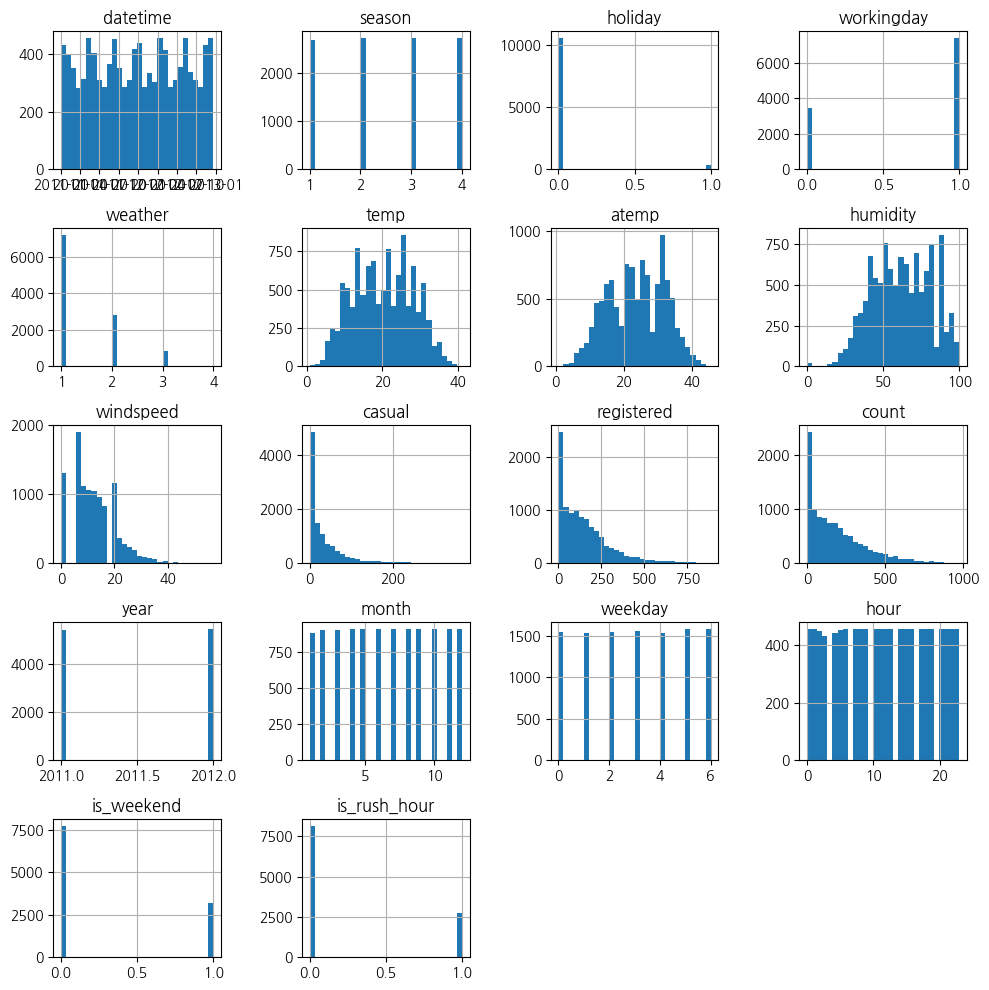

In [745]:
train_df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 2-4. 상관관계 히트맵
상관관계 히트맵 관측 결과, 여러 흥미로운 결과를 얻을 수 있었습니다.

I. 다중공선성 발생 측면에서
1. temp와 atemp는 매우 강한 상관관계를 갖고 있습니다.
2. month와 season 또한 강력한 상관관계를 갖고 있습니다.
3. 결과 레이블에 해당하는 casual, registered와 그 합인 count 또한 강한 상관관계가 있습니다.
4. weekday와 is_weekend 변수 역시 강한 상관관계를 띄고 있습니다.

II. 결과값과의 관계 측면에서
1. is_rush_hour 변수가 registered 변수와 0.53으로 높은 상관관계를 갖고 있습니다.  
출퇴근하는 사람이 많은 가입 예약자가 대부분을 차지하고 있음을 알 수 있습니다.  
반면, casual 변수와의 상관관계는 0.06으로 매우 낮습니다.  

2. registered 변수와 count와의 상관관계가 0.97입니다.  
이는 대부분의 예약 건수가 가입자에게서 나온다는 것을 시사합니다.  

3. temp(온도)와의 관계가 0.39입니다. 엄청나게 높진 않지만, 나름대로 유의미한 값이죠.   
casual 변수와는 0.47정도의 값으로, 제법 유의미한 상관관계를 보여주고 있습니다.  
registered 변수와는 0.32정도로, 비가입자가 가입자에 비해서 따뜻한 날씨를 선호하는 것을 알 수 있습니다.  
이는 미가입자들이 온도에 영향을 많이 받는다고 해석할 수 있겠습니다.  

4. humidity(습도)와의 관계가 -0.32입니다. 이 또한 엄청나게 높은 음의 상관관계는 아닙니다만,    
어느정도 연관이 있다고 해석할 수 있겠습니다.    
온도와 마찬가지로, 비가입자가 좀더 습한 날씨를 선호하지 않습니다.   

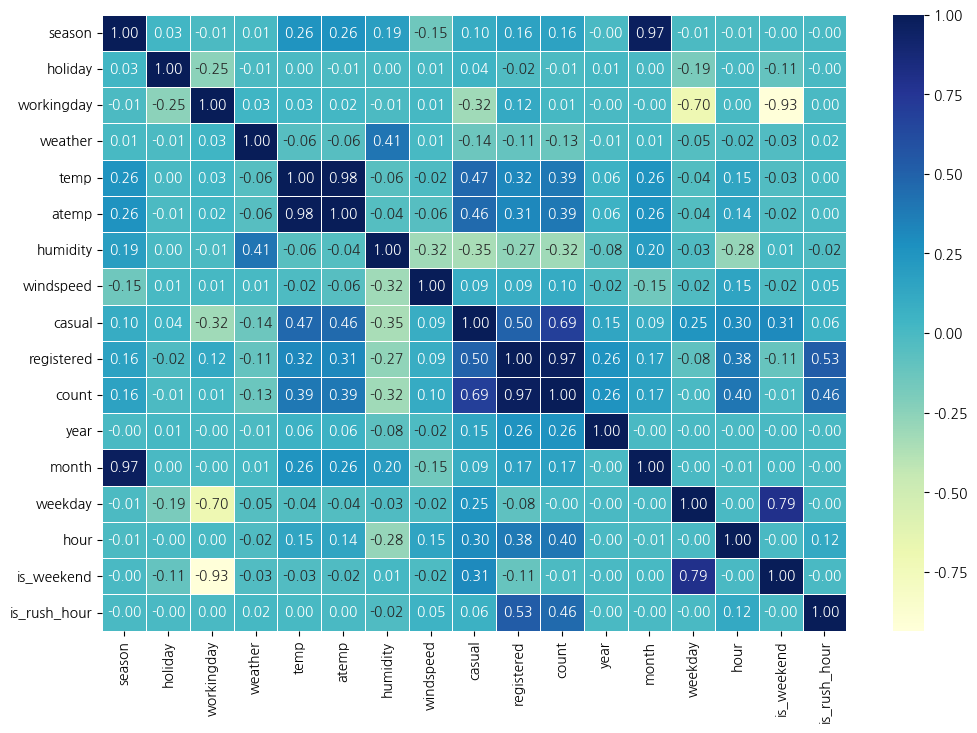

In [746]:
# 먼저 연속형 데이터만 선정
seq = train_df.select_dtypes(include='number') # 수치형 선택
corr = seq.corr(method='pearson')
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5)
plt.show()

### 3. 가설 설정과 검증 

가설을 설정하고, 이를 기반으로 데이터를 분석합니다. 

1. 범주형 변수별 가설 
    - 1-1. 특정 시간대의 자전거 대여 패턴은 무엇인가요?
    - 1-2. 날씨 변수와 자전거 대여 수요 간의 상관관계는 무엇인가요?
    - 1-3. 계절별 자전거 대여 패턴의 차이는 무엇인가요?
    - 1-4. 주말과 평일의 자전거 대여 수요 차이는 무엇인가요?

2. 수치형 변수별 가설 
    - 2-1. 온도 별로 대여 패턴이 어뗗게 변화하나요?
    - 2-2. 습도별 대여 패턴은 어떻게 변화하나요? 
    - 2-3. 풍속과 대여 패턴은 어떤 관계가 있나요? 

3. 모델 성능에 가장 중요한 변수

#### 3-1. 범주형 변수별 가설 분석
변수 별로 count를 확인하여 전체적인 경향을 확인합니다.  

1. 특정 시간대의 자전거 대여 패턴은 무엇인가요?
2. 날씨 변수와 자전거 대여 수요 간의 상관관계는 무엇인가요?
3. 계절별 자전거 대여 패턴의 차이는 무엇인가요?
4. 주말과 평일의 자전거 대여 수요 차이는 무엇인가요?

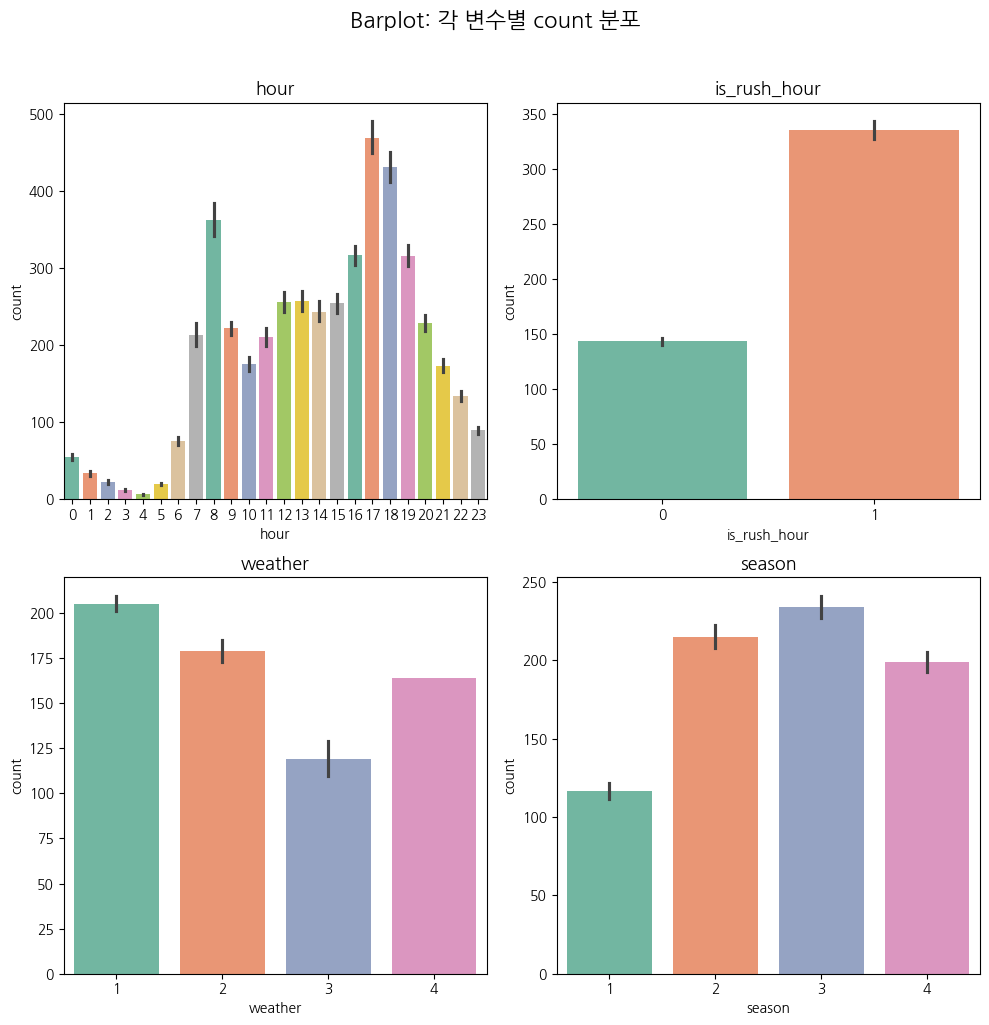

In [747]:

cols = ['hour', 'is_rush_hour', 'weather', 'season']

n_cols = 2
n_rows = -(-len(cols) // n_cols)  # 올림 나눗셈

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.barplot(
        data=train_df,
        x=col,
        y='count',
        ax=axes[i],
        hue=col,        # x와 동일한 변수 지정
        legend=False,   # 범례 제거
        palette='Set2'
    )
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.suptitle('Barplot: 각 변수별 count 분포', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##### 분석 결과

1. 특정 시간대의 자전거 대여 패턴은 무엇인가요?

- 분석 결과  
    - 출퇴근 시간대(is_rush_hour)에는 대여량이 그렇지 않은 시간대보다 3배 더 높습니다. 
    - 출퇴근 시간대 외에도 지켜보면 좋은 포인트는 23시~05시까지의 분포입니다. 밤에는 대여량이 급락하는 것을 볼 수 있습니다.

2. 날씨 변수와 자전거 대여 수요 간의 상관관계는 무엇인가요?

- 분석 결과  
    - 맑은 날씨일수록 대여량이 높습니다. 
    - 의외인 포인트는 날씨가 폭우/폭설일 때도 대여량이 높은 모습을 띈다는 것입니다.  

3. 계절별 자전거 대여 패턴의 차이는 무엇인가요?

- 분석 결과  
    - 봄에는 대여량이 매우 낮은 모습을 확인할 수 있습니다. 
    - 여름, 가을, 겨울에는 분포가 비슷한 편이지만, 가을에 대여량이 높은 것을 확인할 수 있었습니다. 

4. 주말과 평일의 자전거 대여 수요 차이는 무엇인가요?

- 분석 결과
    - 주말에는 대여 수요가 높을 것 같았는데, 예상 외로 크게 차이가 없었습니다.

#### 3-2. 수치형 변수 가설 분석 
1. 온도 별로 대여 패턴이 어뗗게 변화하나요?
2. 습도별 대여 패턴은 어떻게 변화하나요? 
3. 풍속과 대여 패턴은 어떤 관계가 있나요? 

In [748]:
eda_df = train_df.copy()

# temp
eda_df['temp_cat'] = pd.cut(
    eda_df['temp'],
    bins=[0, 10, 20, 30, eda_df['temp'].max()],
    labels=['추움(0-10)', '선선함(10-20)', '따뜻함(20-30)', '더움(30+)'],
    include_lowest=True
)

# atemp
eda_df['atemp_cat'] = pd.cut(
    eda_df['atemp'],
    bins=[0, 10, 20, 30, eda_df['atemp'].max()],
    labels=['추움(0-10)', '선선함(10-20)', '따뜻함(20-30)', '더움(30+)'],
    include_lowest=True
)

# humidity
eda_df['humidity_cat'] = pd.cut(
    eda_df['humidity'],
    bins=[0, 40, 60, 80, 100],
    labels=['건조(0-40)', '보통(40-60)', '습함(60-80)', '매우습함(80+)'],
    include_lowest=True
)

# windspeed
eda_df['windspeed_cat'] = pd.cut(
    eda_df['windspeed'],
    bins=[0, 10, 20, 30, eda_df['windspeed'].max()],
    labels=['약풍(0-10)', '약간강함(10-20)', '강함(20-30)', '매우강함(30+)'],
    include_lowest=True
)

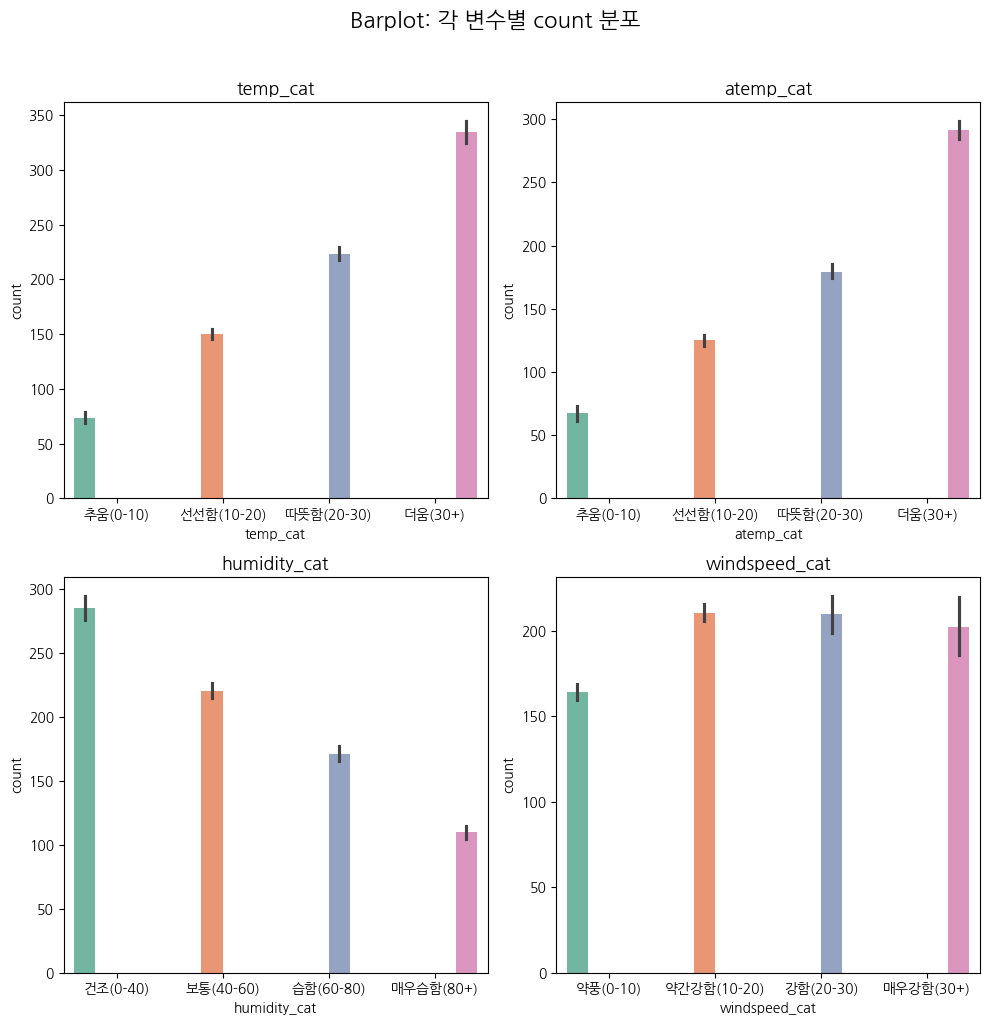

In [749]:
cols = ['temp_cat', 'atemp_cat', 'humidity_cat', 'windspeed_cat']

n_cols = 2
n_rows = -(-len(cols) // n_cols)  # 올림 나눗셈

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.barplot(
        data=eda_df,
        x=col,
        y='count',
        ax=axes[i],
        hue=col,        # x와 동일한 변수 지정
        legend=False,   # 범례 제거
        palette='Set2'
    )
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.suptitle('Barplot: 각 변수별 count 분포', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##### 분석 결과

1. 온도 별로 대여 패턴이 어뗗게 변화하나요?

- 분석 결과 
    - 전체적으로 따뜻할 수록 대여량이 상승하는 모습을 보였습니다. 
    - temp, atemp 사이에는 큰 차이를 확인할 수 없었습니다.

2. 습도별 대여 패턴은 어떻게 변화하나요? 

- 분석 결과
    - 전반적으로 낮은 습도를 선호하는 모습을 보입니다. 
    - 습도가 높을수록 대여량이 감소하는 패턴을 확인할 수 있습니다. 

3. 풍속과 대여 패턴은 어떤 관계가 있나요? 

- 분석 결과 
    - 풍속에 따라서 크게 대여량이 변화하지 않는 모습을 보입니다. 
    - 풍속이 강함, 매우 강함이어도 대여량이 비슷한 것으로 보아하니, 데이터 자체에 노이즈가 많이 낀 것으로 보입니다. 
    - 머신 러닝시에는 크게 도움이 되지 않을 것으로 보여서, 제거하는 것도 검토할만 해 보입니다. 

### 3. 모델 성능에 가장 중요한 변수 

hour과 is_rush_hour 변수로 보입니다. 
이유는, 다른 변수들에 비해서 대여량의 차이가 도드라지게 보여지기 때문입니다. 

### 4. 데이터 전처리
머신러닝에서 중요한 데이터 전처리 과정입니다.
앞서 초기분석에서 살펴본 결과, 데이터에 결측값은 존재하지 않았으므로 결측값 처리는 별도로 처리하지 않습니다.

#### 데이터 스케일링
일반적인 수치형 데이터에 해당하는 temp와 humidity에 Z-Score 스케일링을 수행합니다.
또한, 년도값이 지나치게 커서 데이터 학습에 방해가 될 수 있으니 이를 1, 2, 3 꼴로 만들어 줍니다.
풍속 같은 경우에는 데이터가 심하게 우편향되어있어 로그 스케일을 취해 줍니다.

결과값은 전체적으로 우편향되어 있지만, 추후에 따로 스케일링을 진행합니다.

#### 범주형 인코딩
다중 클래스 변수인 season, weather에 대해서 범주형 인코딩을 수행합니다.

In [750]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 입력값을 처리하는 전처리기 클래스
class PreProcessor:
    def __init__(self, cat_cols=[],
                 num_cols=[],
                 encoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
                 scaler=StandardScaler()):
        self.cat_cols = cat_cols
        self.num_cols = num_cols
        self.encoder = encoder
        self.scaler = scaler

    # 피쳐 엔지니어링과 년도 스케일링을 적용하는 함수
    def preprocess(df):
        df = PreProcessor.apply_year_scaling(df)

        return df

    # 연도 변수는 1, 2, 3꼴로 변환
    def apply_year_scaling(df):
        df['year'] = df['year'] - 2010
        return df


    def fit(self, df):
        self.encoder.fit(df[self.cat_cols])
        self.scaler.fit(df[self.num_cols])

    def transform(self, df):
        # 범주형 인코딩
        encoded = self.encoder.transform(df[self.cat_cols])
        feature_names = self.encoder.get_feature_names_out(self.cat_cols)
        encoded_df = pd.DataFrame(encoded, columns=feature_names, index=df.index)

        # 수치형 스케일링
        df[self.num_cols] = self.scaler.transform(df[self.num_cols])

        # 합치기
        df = pd.concat([df.drop(columns=self.cat_cols), encoded_df], axis=1)
        return df

    def fit_transform(self, df):
        self.fit(df)
        return self.transform(df)

In [751]:
# 출력값을 처리하는 전처리 함수

def preprocess_target(df):
    df = np.log1p(df)
    return df

def preprocess_targets(df, target_col):
    df[target_col] = np.log1p(df[target_col])
    return df

### 5. 전처리 검증 
전처리 검증을 수행합니다. 
여기서는 결과 변수가 적절하게 스케일링되었는지를 주로 살펴볼 예정입니다.

In [752]:
eda_preprocessor = PreProcessor(cat_cols=[], num_cols=['temp', 'humidity'])
eda_df = PreProcessor.preprocess(train_df.copy())
eda_transformed_df = eda_preprocessor.fit_transform(eda_df)
eda_transformed_df = preprocess_targets(eda_transformed_df, ['casual', 'registered', 'count'])

eda_transformed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      10886 non-null  datetime64[us]
 1   season        10886 non-null  int64         
 2   holiday       10886 non-null  int64         
 3   workingday    10886 non-null  int64         
 4   weather       10886 non-null  int64         
 5   temp          10886 non-null  float64       
 6   atemp         10886 non-null  float64       
 7   humidity      10886 non-null  float64       
 8   windspeed     10886 non-null  float64       
 9   casual        10886 non-null  float64       
 10  registered    10886 non-null  float64       
 11  count         10886 non-null  float64       
 12  year          10886 non-null  int32         
 13  month         10886 non-null  int32         
 14  weekday       10886 non-null  int32         
 15  hour          10886 non-null  int32         
 1

#### 히스토그램
전처리 과정에서, 우편향 데이터인 casual, registerd, count를 대상으로 로그 스케일을 적용하였습니다.   
이로 인해서 해당 값들이 정규분포로 변하였는지를 관측하였습니다.   

**결과**
목표 변수들(casual, registered, count)는 정규분포에 가까워졌음을 확인할 수 있었습니다.   

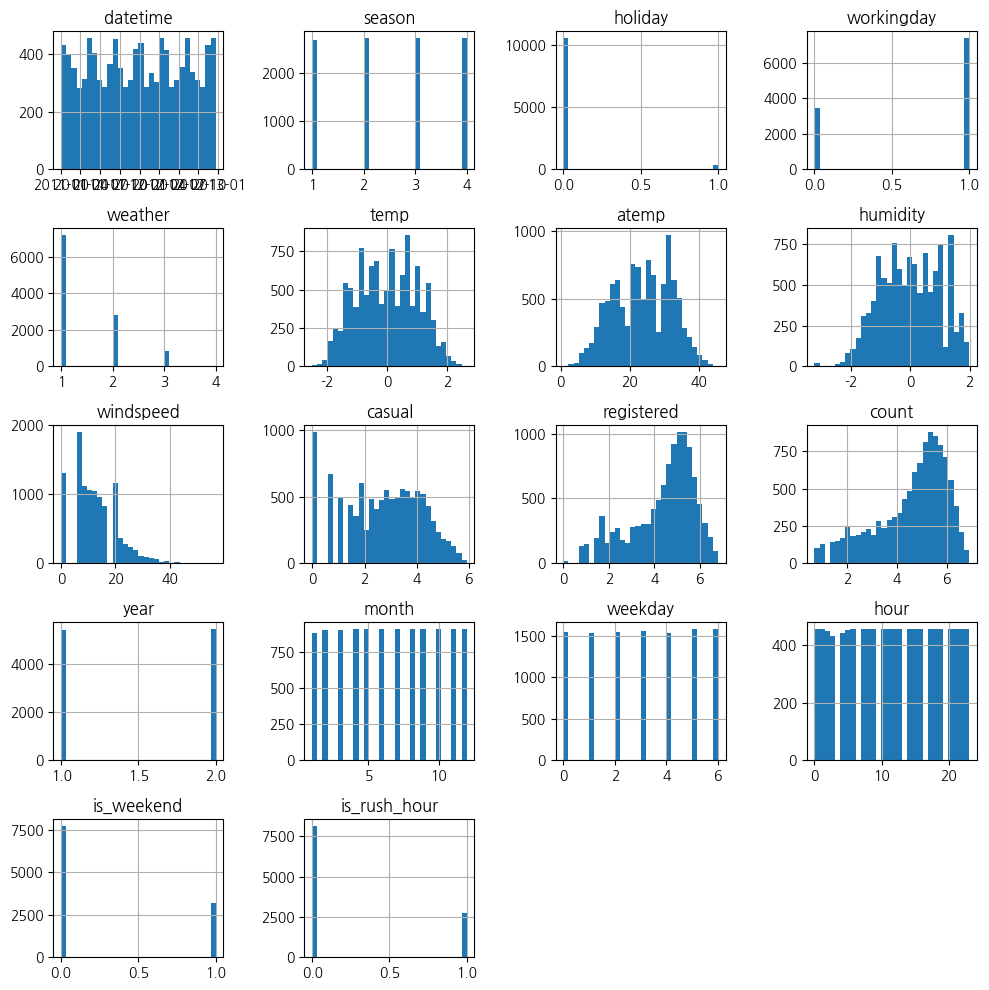

In [753]:
eda_transformed_df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

## III. 모델링 및 성능 평가

### 1. 입력 변수, 결과 변수 선정
EDA 결과 상으로, 다중공선성 발생이 가능한 변수는 제거합니다.     
또한, 명백하게 의미가 없어보이는 변수는 미리 제거합니다.  

#### 선정 결과
##### 1. 입력 변수
- 숫자형: temp, humidity, year,  hour
- 범주형: season, holiday, workingday, weather, is_strong_wind, is_weekend, is_rush_hour   
- atemp, weekday, season변수는 다중공선성 발생 가능성이 높으므로 제거합니다.    
- windspeed 변수는 노이즈가 너무 많이 섞여있어, 입력변수에서 제거합니다. 

##### 2. 결과 변수
- **count**: 모델에 직접 count값을 학습시키는 통합 케이스입니다.     
- **casual, registered**: casual과 registered를 따로따로 학습시키는 분리 케이스입니다.   

결과 변수를 count 하나로 잡는게 아니라, 통합 케이스와 분리 케이스 둘 모두 살펴볼 예정입니다.  

In [754]:
X = train_df.copy()
X = PreProcessor.preprocess(X)
X.drop(columns=['atemp', 'casual', 'registered', 'count', 'datetime', 'season', 'windspeed'], inplace=True)
INTEGRATED_Y = train_df['count']
SEPARATED_Y = train_df[['casual', 'registered']]

### 2. 데이터 세트 구성 및 데이터 전처리
학습/테스트 데이터 분리를 수행합니다.

데이터 누수를 막기 위해서 학습/테스트 데이터 분리 후 데이터 전처리를 진행합니다.  

In [755]:
from sklearn.model_selection import train_test_split

x_train, x_test, iy_train, iy_test, sy_train, sy_test = train_test_split(
    X, INTEGRATED_Y, SEPARATED_Y, test_size=0.2, random_state=42
)

# 결과 저장 구조
results = {
    "통합모델": {"x_train": x_train, "x_test": x_test, "y_train": iy_train, "y_test": iy_test, "pred": None},
    "분리모델": {"x_train": x_train, "x_test": x_test, "y_train": sy_train, "y_test": sy_test, "pred": None},
}

print(results["통합모델"]["x_train"].shape, results["통합모델"]["y_train"].shape)

(8708, 11) (8708,)


In [756]:
# X값 대상으로 전처리

x_preprocessor = PreProcessor(cat_cols=['weather'], num_cols=['temp', 'humidity'])
x_train = x_preprocessor.fit_transform(x_train)
x_test = x_preprocessor.transform(x_test)

# y값 대상으로 전처리
iy_train = preprocess_target(iy_train)
iy_test = preprocess_target(iy_test)
sy_train = preprocess_targets(sy_train, ['casual', 'registered'])
sy_test = preprocess_targets(sy_test, ['casual', 'registered'])

### 3. 모델 세팅
학습에 사용될 모델의 베이스라인을 구성합니다.

사용된 모델은 다음과 같습니다.
- Random Forest
- KNN
- Linear Regression
- Ridge
- Lasso
- Bayesian Ridge
- SGD  


In [757]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
import numpy as np

models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=0.1),
    "Lasso": Lasso(alpha=0.01),
    "BayesianRidge": BayesianRidge(),
    "SGD": SGDRegressor(
        max_iter=2000,
        tol=1e-3,
        penalty='elasticnet',
        alpha=0.0001,
        random_state=42
    ),
    "KNN": KNeighborsRegressor(
        n_neighbors=7,
        metric='manhattan'
    ),
}


def run_integrated_models(models, x_train, y_train, x_test, y_test):
    results_table = []

    for name, model in models.items():
        # 모델 학습 (log1p 상태)
        model.fit(x_train, y_train)
        log_pred = model.predict(x_test)

        #  로그 → 원래 스케일 복구
        pred = np.expm1(log_pred)
        true = np.expm1(y_test)

        # RMSLE
        rmsle = np.sqrt(mean_squared_log_error(true, pred))

        # R2 Score
        r2 = r2_score(y_test, log_pred)

        results_table.append({
            "모델": name,
            "RMSLE": rmsle,
            "R2": r2
        })

    return pd.DataFrame(results_table).sort_values("RMSLE").set_index("모델")

def run_separated_models(models, x_train, y_train, x_test, y_test):
    results_table = []

    for name, model in models.items():
        # casual 학습
        model.fit(x_train, y_train['casual'])
        casual_pred = model.predict(x_test)

        # registered 학습
        model.fit(x_train, y_train['registered'])
        registered_pred = model.predict(x_test)

        # 로그 상태에서 합산
        log_pred = casual_pred + registered_pred
        log_true = y_test['casual'] + y_test['registered']

        rmsle = np.sqrt(mean_squared_log_error(np.expm1(log_true), np.expm1(log_pred)))


        # R2 (로그 스케일 기준)
        r2 = r2_score(log_true, log_pred)

        results_table.append({
            "모델": name,
            "RMSLE": rmsle,
            "R2": r2
        })

    return pd.DataFrame(results_table).sort_values("RMSLE").set_index("모델")

### 4. 모델 학습 및 평가

In [758]:
integrated_models = run_integrated_models(models, x_train, iy_train, x_test, iy_test)
seperated_models = run_separated_models(models, x_train, sy_train, x_test, sy_test)

In [759]:
integrated_models

,RMSLE,R2
모델,,
RandomForest,0.299620,0.956390
KNN,0.365197,0.935211
BayesianRidge,0.912430,0.595566
LinearRegression,0.912434,0.595563
Ridge,0.912434,0.595563
Lasso,0.913740,0.594405
SGD,0.927984,0.581660


In [760]:
seperated_models

,RMSLE,R2
모델,,
RandomForest,0.640427,0.946284
KNN,0.732197,0.929787
LinearRegression,1.679388,0.630628
Ridge,1.679389,0.630628
BayesianRidge,1.679420,0.630614
Lasso,1.682740,0.629153
SGD,1.688868,0.626447


#### 4-1. 모델 성능 비교 및 분석

전체적으로 Random Forest, KNN 모델이 높은 성능을 보여주고 있고, 선형 기반 모델들은 제대로 데이터를 탐지하지 못하고 있습니다.  
이는 데이터가 선형 관계가 아니라, 비선형적 관계를 띄고 있음을 강하게 시사합니다.  

또한 전체적으로 통합 모델의 지표가 분리 모델에 비해서 뛰어난 모습을 보이고 있습니다.
아래 표는, 초기 BaseLine 기준으로 측정했던 모델들의 성능표입니다. (현재 BaseLine과는 맞지 않는 수치일 수 있습니다.)

| 모델             | 유형   | RMSLE      | R²        |
|------------------|--------|------------|-----------|
| RandomForest     | 통합   | **0.298865** | **0.956609** |
| KNN              | 통합   | 0.371454   | 0.932972  |
| RandomForest     | 분류   | 0.640264   | 0.946312  |
| KNN              | 분류   | 0.743890   | 0.927527  |
| LinearRegression | 통합   | 0.905929   | 0.601309  |
| Ridge            | 통합   | 0.905929   | 0.601309  |
| BayesianRidge    | 통합   | 0.905931   | 0.601307  |
| SGD              | 통합   | 0.906639   | 0.600684  |
| Lasso            | 통합   | 0.907985   | 0.599498  |
| LinearRegression | 분류   | 1.658362   | 0.639820  |
| Ridge            | 분류   | 1.658363   | 0.639819  |
| BayesianRidge    | 분류   | 1.658407   | 0.639800  |
| SGD              | 분류   | 1.661144   | 0.638610  |
| Lasso            | 분류   | 1.663396   | 0.637630  |

#### 4-2. 최종 모델 선정  

통합 모델의 RandomForest가 가장 뛰어난 지표를 보였으므로, 
해당 모델을 선정합니다. 

선정된 모델: 

| 모델             | 유형   | RMSLE      | R²        |
|------------------|--------|------------|-----------|
| RandomForest     | 통합   | **0.298865** | **0.956609** |

In [761]:
run_integrated_models(models, x_train, iy_train, x_test, iy_test)
model = models["RandomForest"]

model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample